In [21]:
# imports

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import random_split

from torch.utils.data import TensorDataset, DataLoader
import fitsio
import matplotlib.pyplot as plt

# METAL_LINES_LIST = {
#     "SiII_1190": 1190.4158,
#     "SiII_1193": 1193.2897,
#     "SiIII_1207": 1206.500,
#     "SiII_1260": 1206.500,
#     "CIV_1548": 1548.2049,
#     "CIV_1550": 1550.77845,
#     'MgI(2853)': 2852.96,
# }

### Check transmission file from P1D code

Wavelength shape: (31001,)
Single flux shape: (31001,)


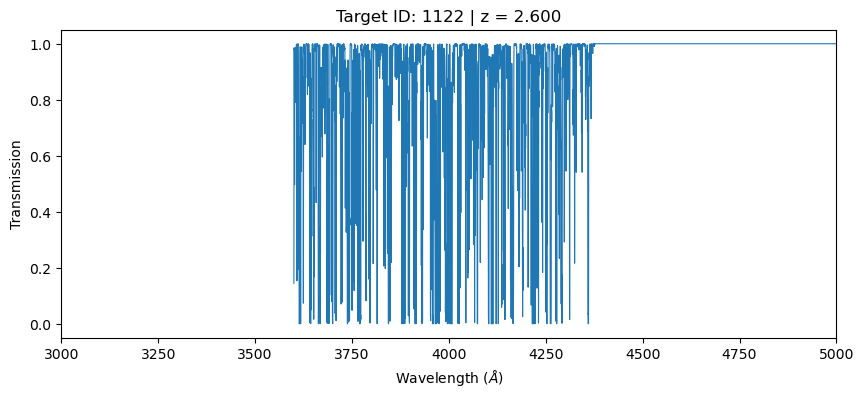

In [22]:
# load transmission file (preprocessed)
p1d_file = '/global/cfs/cdirs/desicollab/users/mherbold/p1d_mocks/DR1/QQ_output_test/transmission-16-1_2.fits'

# Read arrays
meta = fitsio.read(p1d_file, ext="METADATA")
wave = fitsio.read(p1d_file, ext="WAVELENGTH")
fluxes = fitsio.read(p1d_file, ext="TRANSMISSION")

# Pick single spectrum index
i = 100

# Extract and squeeze shape
single_flux = fluxes[i].squeeze()
target_id = meta["MOCKID"][i]
z = meta["Z"][i]

# Check shapes directly
print(f"Wavelength shape: {wave.shape}")        # Output: (31001,)
print(f"Single flux shape: {single_flux.shape}")  # Output: (31001,)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(wave, single_flux, lw=0.8)
plt.xlabel(r"Wavelength ($\AA$)")
plt.ylabel("Transmission")
plt.title(f"Target ID: {target_id} | z = {z:.3f}")
plt.xlim(3000,5000)
plt.show()

### Generate training samples

In [23]:
def generate_spectral_dataset(
    lya_flux_samples: np.ndarray,
    wave_grid: np.ndarray,
    A_min: float = 0.01,
    A_max: float = 1.0, # A = 1, same strength as Lya absorption
    num_samples: int = 1000,
    lya_wave: float = 1215.67,
    metal_wave: float = 1260.42,
    snr: float = 30.0,
    seed: int = 123
    ) -> TensorDataset:
    """
    Generates synthetic 2-channel optical depth training pairs from LyA flux spectra
    with exact cosmological redshift mapping for metal absorption features.

    Parameters:
    -----------
    lya_flux_samples : np.ndarray
        Array of shape (N_input, N_pixels) containing pure LyA transmission fluxes (0 to 1).
    wave_grid : np.ndarray
        1D array of shape (N_pixels,) representing the observed wavelength grid (e.g., in Angstroms).
    A_min, A_max : float
        Min and max scale factors for the metal absorption signal.
        When A_max = 1, this is the same strength as the Lya absorption. 
        When A_min = 0.01, this is scaled down to 1% of Lya absorption. 
    num_samples : int
        Number of output training spectra to generate.
    lya_wave, metal_wave : float
        Rest wavelengths for LyA and the target metal line (e.g., Si II 1260.42).
    snr : float
        Signal-to-Noise Ratio per pixel for flux noise injection.
        e.g. SNR = 30, then standard deviation per pix = 1/30 ~ 0.033 
        For NO noise, pass SNR ~ 1e6, or modify noise = 0
    seed : int
        Random seed for reproducibility.

    Returns:
    --------
    TensorDataset yielding (X, y) where:
        X shape: (2, N_pixels) -> [tau_obs, tau_obs_shifted]
        y shape: ()           -> log10(A)
    """
    np.random.seed(seed)
    n_input, n_pixels = lya_flux_samples.shape

    # Ratio > 1.0 when metal_wave > lya_wave (e.g., 1260.42 / 1215.67 = 1.0368)
    ratio = metal_wave / lya_wave

    # Pre-compute look-up wavelength grids for redshift transformation
    # 1. Where to lookup LyA tau to place metal absorption on wave_grid
    wave_lookup_for_metal = wave_grid / ratio

    # 2. Where to lookup observed tau to shift metal features back onto LyA features for Channel 2
    wave_metal_obs = wave_grid * ratio

    X_data = np.zeros((num_samples, 2, n_pixels), dtype=np.float32)
    y_data = np.zeros(num_samples, dtype=np.float32)

    # Convert input flux pool to optical depth: tau = -ln(F)
    tau_lya_inputs = -np.log(np.clip(lya_flux_samples, 1e-4, 1.0))

    for i in range(num_samples):
        # Sample a random LyA spectrum from input pool
        rand_idx = np.random.randint(0, n_input)
        tau_lya = tau_lya_inputs[rand_idx]

        # Draw scale factor A uniformly in log10 space
        log10_A = np.random.uniform(np.log10(A_min), np.log10(A_max))
        A = 10.0 ** log10_A

        # Interpolate LyA optical depth to compute metal forest contribution at each pixel
        tau_metal_on_grid = np.interp(
            wave_lookup_for_metal, wave_grid, tau_lya, left=0.0, right=0.0
        )

        # Combine components in optical depth space
        tau_true_total = tau_lya + A * tau_metal_on_grid

        # Convert to flux space to inject realistic spectrograph noise
        flux_true = np.exp(-tau_true_total)
        # noise = np.random.normal(0.0, 1.0 / snr, size=n_pixels)
        # flux_obs = np.clip(flux_true + noise, 1e-4, 1.5)
        
        # Handle infinite / disabled noise
        if snr is None or snr >= 1e5:
            flux_obs = flux_true
        else:
            noise = np.random.normal(0.0, 1.0 / snr, size=n_pixels)
            flux_obs = np.clip(flux_true + noise, 1e-4, 1.5)
            
        # Convert noisy flux back to optical depth
        tau_obs = -np.log(np.clip(flux_obs, 1e-4, 1.0))

        # Channel 2: Shift tau_obs by wave_metal_obs so that metal absorption features
        # in Channel 2 align perfectly in pixel index with LyA absorption features in Channel 0
        tau_obs_shifted = np.interp(
            wave_metal_obs, wave_grid, tau_obs, left=0.0, right=0.0
        )

        # Store in output arrays
        X_data[i, 0, :] = tau_obs
        X_data[i, 1, :] = tau_obs_shifted
        y_data[i] = log10_A

    # Package as PyTorch TensorDataset
    X_tensor = torch.from_numpy(X_data)
    y_tensor = torch.from_numpy(y_data)
    # return TensorDataset(X_tensor, y_tensor)
    return TensorDataset(torch.from_numpy(X_data), torch.from_numpy(y_data))


In [24]:
# # Verification Script

# if __name__ == "__main__":
#     # Generate synthetic wavelength grid and dummy LyA flux spectra
#     N_pixels = 2048
#     wave = np.linspace(4000.0, 4500.0, N_pixels)  # Observed wavelength grid in Angstroms

#     # Create 50 dummy LyA spectra with absorption troughs
#     dummy_lya_flux = np.ones((50, N_pixels))
#     for k in range(50):
#         lines = np.random.choice(N_pixels, size=30, replace=False)
#         dummy_lya_flux[k, lines] = 0.2

#     # Generate training dataset
#     dataset = generate_spectral_dataset(
#         lya_flux_samples=dummy_lya_flux,
#         wave_grid=wave,
#         A_min=0.001,
#         A_max=5.0,
#         num_samples=1000,
#         lya_wave=1215.67,
#         metal_wave=1260.42,  # Si II 1260
#         snr=30.0,
#         seed=42
#     )

#     # Instantiate PyTorch DataLoader
#     train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

#     # Verify shape outputs
#     x_batch, y_batch = next(iter(train_loader))
#     print(f"Generated {len(dataset)} training samples.")
#     print(f"X batch tensor shape: {x_batch.shape}")  # Should be [32, 2, 2048]
#     print(f"y batch tensor shape: {y_batch.shape}")  # Should be [32]

In [51]:
# Generate training dataset 
dataset = generate_spectral_dataset(
        lya_flux_samples=fluxes,
        wave_grid=wave,
        A_min=0.2, 
        A_max=1.0, 
        num_samples=1000,
        lya_wave=1215.67,
        metal_wave=2852.96,  # MgI(2853)
        # snr=10.0,
        snr = None, # NO noise for proof of concept
        seed=123
    )

# Instantiate PyTorch DataLoader
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Verify shape outputs
x_batch, y_batch = next(iter(train_loader))
print(f"Generated {len(dataset)} training samples.")
print(f"X batch tensor shape: {x_batch.shape}")  # Should be [32, 2, 2048]
print(f"y batch tensor shape: {y_batch.shape}")  # Should be [32]

Generated 1000 training samples.
X batch tensor shape: torch.Size([32, 2, 31001])
y batch tensor shape: torch.Size([32])


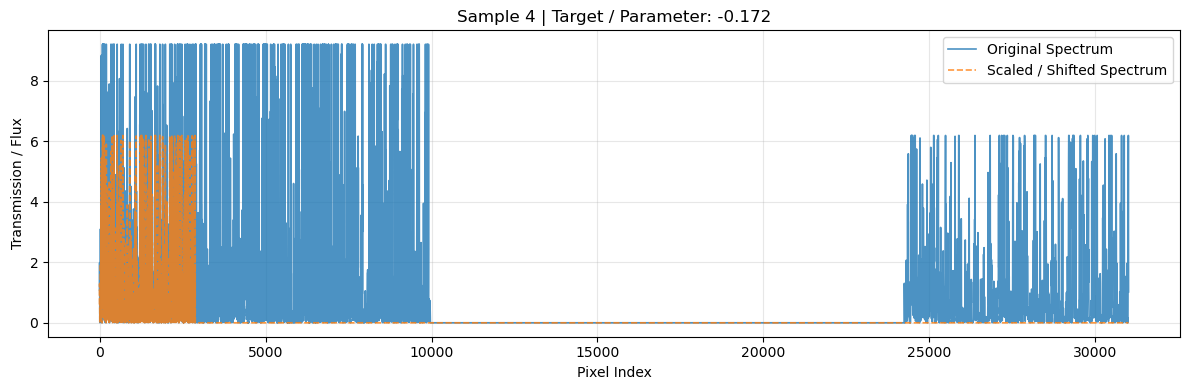

In [52]:
# Grab a single batch from the DataLoader (or indexing dataset directly)
x_batch, y_batch = next(iter(train_loader))

# Select a sample index to visualize (0 to batch_size - 1)
sample_idx = 4

# Extract the channels: original and scaled/shifted spectra
# PyTorch tensors need to be converted to NumPy arrays
spec_orig = x_batch[sample_idx, 0, :].detach().cpu().numpy()
spec_mod = x_batch[sample_idx, 1, :].detach().cpu().numpy()
label = y_batch[sample_idx].item()

# Plot single sample comparison
plt.figure(figsize=(12, 4))
plt.plot(spec_orig, label="Original Spectrum", alpha=0.8, lw=1.2)
plt.plot(
    spec_mod, label="Scaled / Shifted Spectrum", alpha=0.8, lw=1.2, ls="--"
)

plt.xlabel("Pixel Index")
plt.ylabel("Transmission / Flux")
plt.title(f"Sample {sample_idx} | Target / Parameter: {label:.3f}")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Setting up the CNN Architecture

In [53]:
class SpectralMetalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 1D Conv backbone to extract multi-scale cross-correlation features
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)  # Pools variable pixel dimensions to shape (B, 256, 1)
        )
        # Regression head predicting log10(A)
        self.regressor = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.features(x)
        feat = torch.flatten(feat, 1)
        out = self.regressor(feat)
        return out.squeeze(-1)  # Shape: (batch_size,)

In [54]:
# 1. Train/Validation Split (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

# 2. Hardware configuration, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpectralMetalCNN().to(device)
criterion = nn.SmoothL1Loss()
# SmoothL1Loss = MSE for small error, L1 for large errors
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)


# 3. Training Loop
epochs = 30
train_losses = []
val_losses = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        preds = model(X_b)
        loss = criterion(preds, y_b)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_b.size(0)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            preds = model(X_b)
            val_loss += criterion(preds, y_b).item() * X_b.size(0)

    train_loss /= len(train_set)
    val_loss /= len(val_set)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

Epoch 05/30 | Train Loss: 0.0066 | Val Loss: 0.0062
Epoch 10/30 | Train Loss: 0.0040 | Val Loss: 0.0035
Epoch 15/30 | Train Loss: 0.0029 | Val Loss: 0.0027
Epoch 20/30 | Train Loss: 0.0020 | Val Loss: 0.0015
Epoch 25/30 | Train Loss: 0.0017 | Val Loss: 0.0012
Epoch 30/30 | Train Loss: 0.0012 | Val Loss: 0.0007


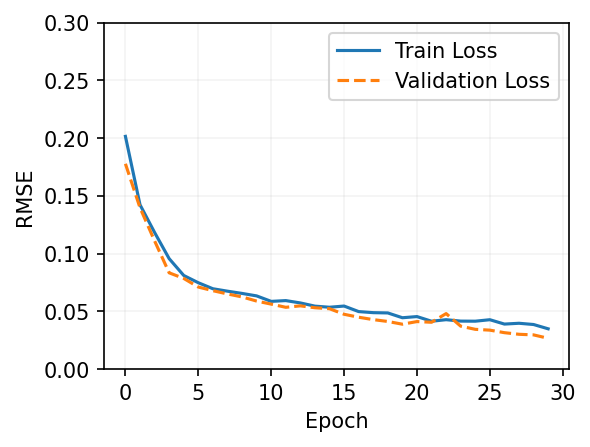

In [55]:
plt.figure(figsize=(4,3), dpi=150)
plt.plot(np.sqrt(train_losses), label='Train Loss')
plt.plot(np.sqrt(val_losses), label='Validation Loss', ls='dashed')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.ylim(0., 0.3)
plt.grid(alpha=0.15)
plt.legend()
plt.show()

#### Run some diagnostics

In [56]:
# def run_dataset_diagnostics(dataset, wave_grid, num_inspect=3):
#     """
#     Plots individual dataset samples and label distributions for quality control.
#     """
#     # 1. Target Label Distribution Check
#     all_y = [y.item() for _, y in dataset]
    
#     fig, axes = plt.subplots(1, 2, figsize=(14, 4))
#     axes[0].hist(all_y, bins=30, color='navy', alpha=0.7, edgecolor='black')
#     axes[0].set_xlabel(r'Target Label $\log_{10}(A)$')
#     axes[0].set_ylabel('Sample Count')
#     axes[0].set_title('Label Distribution Check')
#     axes[0].grid(True, alpha=0.3)
    
#     # SNR noise floor overlay reference
#     axes[1].scatter(range(len(all_y)), all_y, s=10, c=all_y, cmap='viridis', alpha=0.6)
#     axes[1].set_xlabel('Sample Index')
#     axes[1].set_ylabel(r'$\log_{10}(A)$')
#     axes[1].set_title('Sample Parameter Uniformity')
#     axes[1].grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

#     # 2. Channel Overlay & Alignment Inspection
#     for idx in range(num_inspect):
#         X, y = dataset[idx]
#         tau_obs = X[0].numpy()
#         tau_shifted = X[1].numpy()
#         log10_A = y.item()
#         A_val = 10**log10_A

#         fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        
#         # Upper Panel: Channel 0 vs Channel 1 on full grid
#         ax1.plot(wave_grid, tau_obs, label=r'Ch 0: $\tau_{obs}$ (Ly$\alpha$ + Metal)', color='black', lw=0.7, alpha=0.8)
#         ax1.plot(wave_grid, tau_shifted, label=r'Ch 1: $\tau_{shifted}$ (Shifted back)', color='crimson', lw=0.7, alpha=0.6)
#         ax1.set_ylabel(r'Optical Depth $\tau$')
#         ax1.set_title(f'Sample #{idx} | $\log_{{10}}(A) = {log10_A:.3f}$ ($A = {A_val:.4f}$)')
#         ax1.legend(loc='upper right')
#         ax1.grid(True, alpha=0.3)
        
#         # Lower Panel: Zoomed-in crop to verify feature alignment
#         # Pick a window in the middle of the wavelength coverage
#         mid_idx = len(wave_grid) // 2
#         zoom_range = slice(mid_idx, mid_idx + 800)
        
#         ax2.plot(wave_grid[zoom_range], tau_obs[zoom_range], color='black', lw=1.0, label=r'Ch 0 ($\tau_{obs}$)')
#         ax2.plot(wave_grid[zoom_range], tau_shifted[zoom_range], color='crimson', lw=1.0, alpha=0.7, label=r'Ch 1 ($\tau_{shifted}$)')
#         ax2.set_xlabel(r'Observed Wavelength ($\mathrm{\AA}$)')
#         ax2.set_ylabel(r'$\tau$ (Zoomed)')
#         ax2.legend(loc='upper right')
#         ax2.grid(True, alpha=0.3)
        
#         plt.tight_layout()
#         plt.show()

# # Run diagnostics on your generated dataset
# run_dataset_diagnostics(dataset, wave)

In [57]:
def evaluate_spectral_cnn(model, val_loader, device, A_thresh=0.2):
    model.eval()
    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b = X_b.to(device)
            preds = model(X_b)
            y_true_list.extend(y_b.numpy())
            y_pred_list.extend(preds.cpu().numpy())

    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)
    residuals = y_pred - y_true

    # Convert back from log scale to physical linear A space
    A_true = 10.0 ** y_true
    A_pred = 10.0 ** y_pred

    # Calculate metrics
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))

    # --- 1. Parity and Residual Plots ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Parity plot
    axes[0].scatter(y_true, y_pred, alpha=0.6, color="midnightblue", edgecolors="none", s=25)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "r--", lw=2, label="1:1 Line")
    axes[0].set_xlabel(r"True $\log_{10}(A)$")
    axes[0].set_ylabel(r"Predicted $\log_{10}(A)$")
    axes[0].set_title(f"Parity Plot (MAE: {mae:.4f}, RMSE: {rmse:.4f})")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Residual plot
    axes[1].scatter(y_true, residuals, alpha=0.6, color="crimson",
                    edgecolors="none", s=25)
    axes[1].axhline(0, color="black", linestyle="--", lw=1.5)
    axes[1].set_xlabel(r"True $\log_{10}(A)$")
    axes[1].set_ylabel(
        r"Residual ($\log_{10}(A_{\mathrm{pred}}) - "
        r"\log_{10}(A_{\mathrm{true}})$)"
    )
    axes[1].set_title("Residual Analysis")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- 2. Purity & Completeness vs Detection Threshold ---
    log_thresh_val = np.log10(A_thresh)
    
    # Define boolean arrays for thresholding
    is_true_metal = y_true >= log_thresh_val
    is_pred_metal = y_pred >= log_thresh_val

    tp = np.sum(is_true_metal & is_pred_metal)
    fp = np.sum(~is_true_metal & is_pred_metal)
    fn = np.sum(is_true_metal & ~is_pred_metal)
    tn = np.sum(~is_true_metal & ~is_pred_metal)

    purity = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    completeness = tp / (tp + fn) if (tp + fn) > 0 else 1.0

    print(f"--- Performance @ Threshold A >= {A_thresh} (log10(A) >= {log_thresh_val:.2f}) ---")
    print(f"True Positives:  {tp:3d} | False Positives: {fp:3d}")
    print(f"False Negatives: {fn:3d} | True Negatives:  {tn:3d}")
    print(f"Purity (Precision):     {purity:.4f}")
    print(f"Completeness (Recall):  {completeness:.4f}")

    # --- 3. Purity/Completeness Curves across Amplitude Sweep ---
    threshold_sweep = np.linspace(y_true.min(), y_true.max(), 50)
    purities = []
    completenesses = []

    for th in threshold_sweep:
        t_pos = np.sum((y_true >= th) & (y_pred >= th))
        f_pos = np.sum((y_true < th) & (y_pred >= th))
        f_neg = np.sum((y_true >= th) & (y_pred < th))

        pur = t_pos / (t_pos + f_pos) if (t_pos + f_pos) > 0 else 1.0
        comp = t_pos / (t_pos + f_neg) if (t_pos + f_neg) > 0 else 1.0

        purities.append(pur)
        completenesses.append(comp)

    plt.figure(figsize=(8, 4))
    plt.plot(10**threshold_sweep, purities, label="Purity (Precision)", color="teal", lw=2)
    plt.plot(10**threshold_sweep, completenesses, label="Completeness (Recall)", color="darkorange", lw=2)
    plt.xlabel(r"Amplitude Threshold $A$")
    plt.ylabel("Fraction")
    plt.title("Purity & Completeness vs Amplitude Threshold")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()



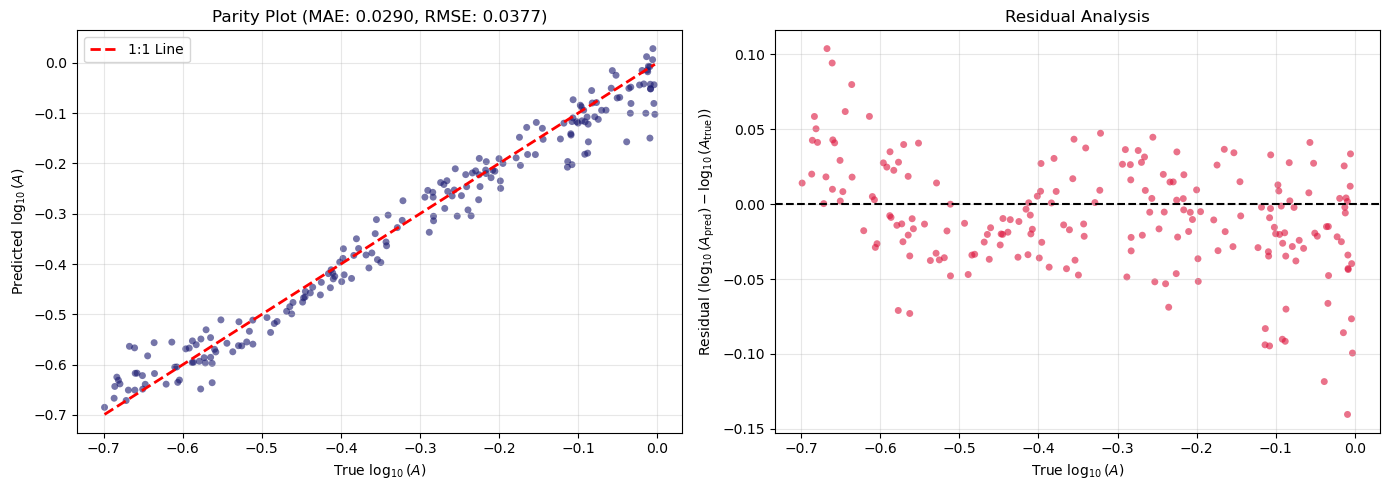

--- Performance @ Threshold A >= 0.2 (log10(A) >= -0.70) ---
True Positives:  200 | False Positives:   0
False Negatives:   0 | True Negatives:    0
Purity (Precision):     1.0000
Completeness (Recall):  1.0000


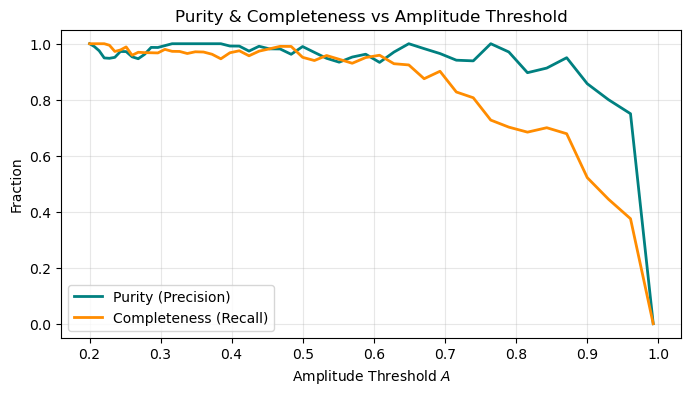

In [59]:
# Run evaluation on validation set
evaluate_spectral_cnn(model, val_loader, device, A_thresh=0.2)